# Import Libraies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
data = pd.read_csv("Titanic-Dataset.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Column Types

- **Numerical** - Age,Fare,PassengerId
- **Categorical** - Survived, Pclass, Sex, SibSp, Parch,Embarked
- **Mixed** - Name, Ticket, Cabin

### Univariate Analysis on `Age`

**Conclusions**

- The `Age` distribution is **approximately normal** with a slight **positive skew**.
- Around **19.9%** of the `Age` values are **missing** and require imputation.
- Most passengers were between **20 and 40 years** old.
- The boxplot indicates the presence of **a few high-age outliers**.
- Missing values can be imputed using the **median** or a more advanced method such as **group-wise median** (e.g., based on `Pclass` and `Sex`).

In [3]:
data['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

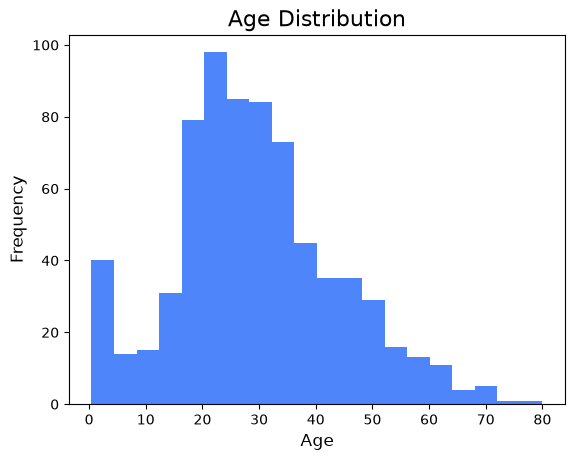

In [64]:
plt.hist(data['Age'], bins=20, color="#4F85FA")
plt.title("Age Distribution", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

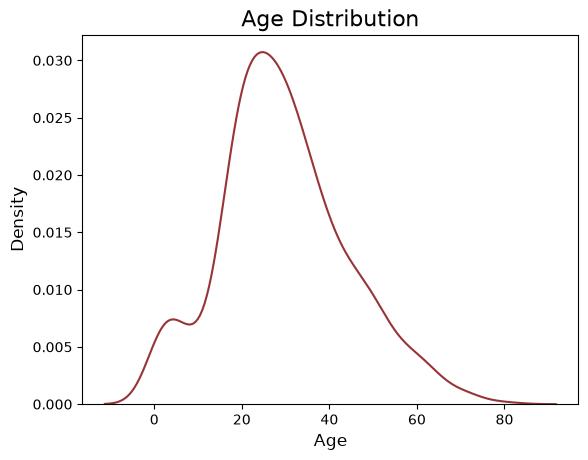

In [65]:
sns.kdeplot(data=data, x='Age', color="#973437")
plt.title("Age Distribution", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

In [6]:
print(data['Age'].skew())

0.38910778230082704


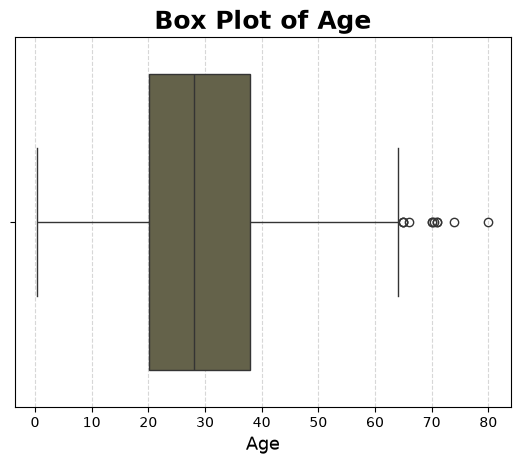

In [66]:
sns.boxplot(data=data, x='Age', color="#686646")
plt.title("Box Plot of Age", fontsize=18, fontweight="bold")
plt.xlabel("Age", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


In [8]:
data[data['Age'] > 65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [9]:
print(data['Age'].isnull().sum())

177


In [10]:
percentage_of_missing_value_in_age = (data['Age'].isnull().sum() / len(data['Age'])) * 100
print(percentage_of_missing_value_in_age)

19.865319865319865


### Univariate Analysis on `Fare`

**Conclusions**

- The `Fare` distribution is **highly positively skewed**.
- Most passengers paid **lower fares**, while a few paid **very high fares**.
- The column contains **many high-value outliers**, as shown in the boxplot.
- `Fare` likely represents the **total ticket fare for a booking/group**, not always the fare per individual.
- A new feature, **`Individual_Fare`**, can be created by dividing the fare by the group size (`SibSp + Parch + 1`).

In [11]:
data['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

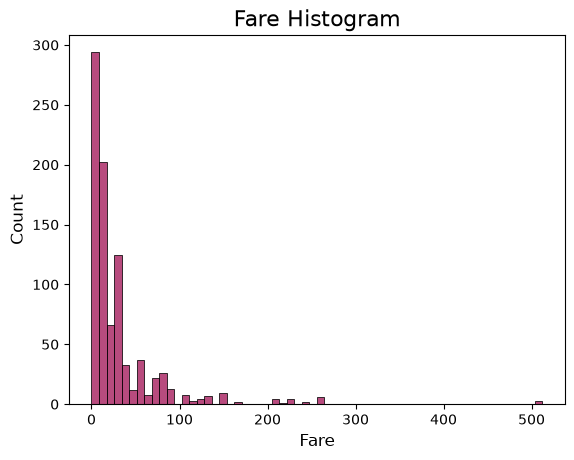

In [12]:
sns.histplot(data=data, x='Fare', color="#A10F53")
plt.title("Fare Histogram", fontsize=16)
plt.xlabel("Fare", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

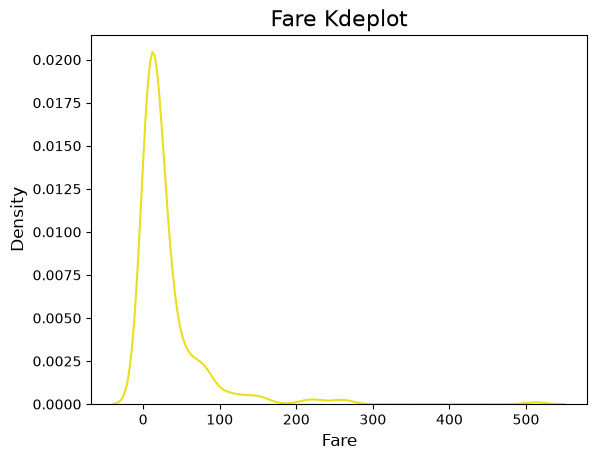

In [13]:
sns.kdeplot(data=data, x='Fare', color="#E9DF1F")
plt.title("Fare Kdeplot", fontsize=16)
plt.xlabel("Fare", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

In [14]:
print(data['Fare'].skew())

4.787316519674893


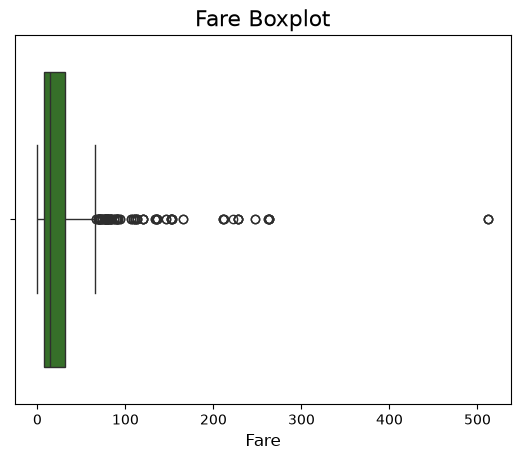

In [15]:
sns.boxplot(data=data, x='Fare', color="#2F7A1E")
plt.title("Fare Boxplot", fontsize=16)
plt.xlabel("Fare", fontsize=12)
plt.show()

In [16]:
data[data['Fare'] > 250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [17]:
print(data['Fare'].isnull().sum())

0


### Univariate Analysis on `Survived`

**Conclusions**

- Around **38.4%** of passengers survived, while **61.6%** did not survive.
- The dataset is **imbalanced**, with more non-survivors than survivors.
- `Survived` is a **binary categorical** target variable (0 = Did Not Survive, 1 = Survived).
- This column will be the **target variable** for bivariate and multivariate analysis to identify factors affecting survival.

In [18]:
data['Survived'].dtype

dtype('int64')

In [19]:
data['Survived'].isnull().sum()

np.int64(0)

In [20]:
data['Survived'].nunique()

2

In [21]:
data['Survived'].unique()

array([0, 1])

In [22]:
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [23]:
data['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

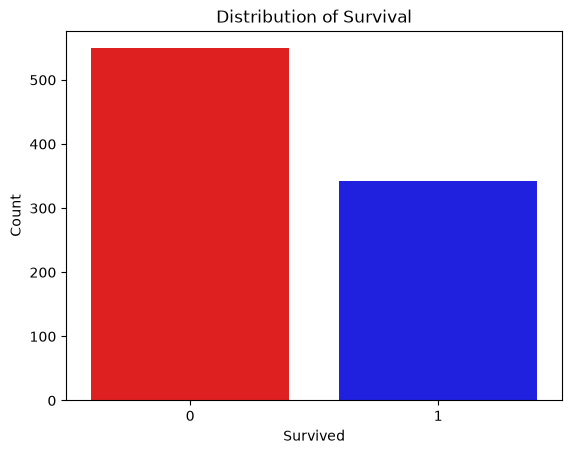

In [24]:
sns.countplot(data=data, x='Survived', palette=['red','blue'])
plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

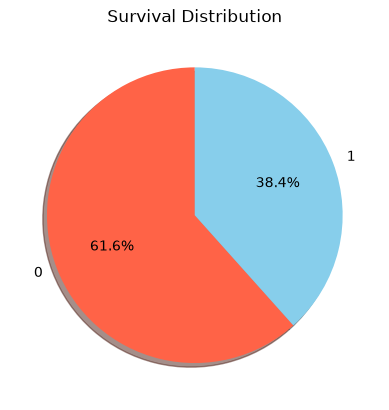

In [25]:
data["Survived"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90,shadow=True,colors=["tomato","skyblue"])
plt.ylabel("")
plt.title("Survival Distribution")
plt.show()

In [27]:
survived = data["Survived"].value_counts()[1]
not_survived = data["Survived"].value_counts()[0]

print(f"Total Passengers : {len(data)}")
print(f"Survived         : {survived}")
print(f"Did Not Survive  : {not_survived}")

print()

print(f"Survival Rate : {(survived/len(data))*100:.2f}%")
print(f"Death Rate    : {(not_survived/len(data))*100:.2f}%")

Total Passengers : 891
Survived         : 342
Did Not Survive  : 549

Survival Rate : 38.38%
Death Rate    : 61.62%


### Univariate Analysis on `Pclass`

**Conclusions**

- `Pclass` is an **ordinal categorical** feature with **no missing values**.
- More than **half of the passengers (55.1%)** traveled in **Third Class**.
- **First Class** and **Second Class** account for **24.2%** and **20.7%** of passengers, respectively.
- The dataset is **imbalanced** across passenger classes, with **Third Class** being the dominant category.
- `Pclass` is likely to be an **important predictor** of survival and should be explored further in bivariate analysis.

In [28]:
data['Pclass'].dtype

dtype('int64')

In [29]:
data['Pclass'].isnull().sum()

np.int64(0)

In [30]:
data['Pclass'].nunique()

3

In [31]:
data['Pclass'].unique()

array([3, 1, 2])

In [32]:
data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [33]:
data['Pclass'].value_counts(normalize=True) * 100

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

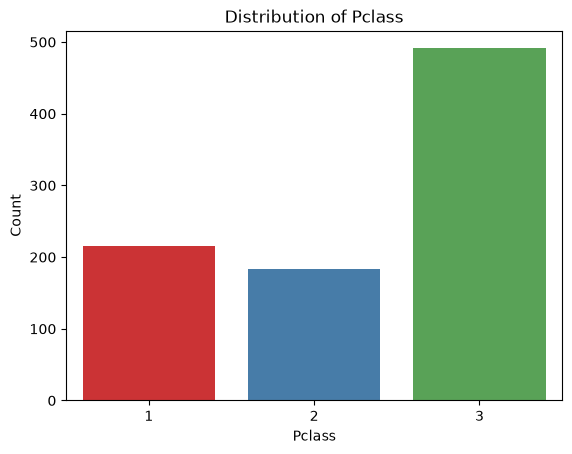

In [36]:
sns.countplot(data=data, x="Pclass", palette="Set1")
plt.title("Distribution of Pclass")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

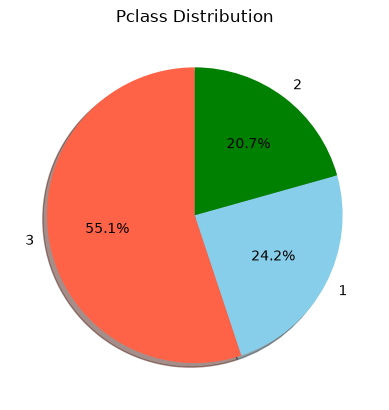

In [38]:
data["Pclass"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90,shadow=True,colors=["tomato","skyblue","green"])
plt.ylabel("")
plt.title("Pclass Distribution")
plt.show()

In [39]:
counts = data["Pclass"].value_counts().sort_index()

print(f"Total Passengers : {len(data)}")
print(f"First Class      : {counts[1]}")
print(f"Second Class     : {counts[2]}")
print(f"Third Class      : {counts[3]}")

print()

print(f"First Class (%)  : {(counts[1]/len(data))*100:.2f}%")
print(f"Second Class (%) : {(counts[2]/len(data))*100:.2f}%")
print(f"Third Class (%)  : {(counts[3]/len(data))*100:.2f}%")

Total Passengers : 891
First Class      : 216
Second Class     : 184
Third Class      : 491

First Class (%)  : 24.24%
Second Class (%) : 20.65%
Third Class (%)  : 55.11%


### Univariate Analysis on `Sex`

**Conclusions**

- `Sex` is a **nominal categorical** feature with **no missing values**.
- Around **64.8%** of passengers were **male**, while **35.2%** were **female**.
- The dataset is **imbalanced**, with nearly **twice as many male passengers** as female passengers.
- `Sex` is expected to be a **strong predictor** of survival and should be analyzed further with the `Survived` column.

In [40]:
data['Sex'].dtype

<StringDtype(na_value=nan)>

In [41]:
data['Sex'].isnull().sum()

np.int64(0)

In [42]:
data['Sex'].nunique()

2

In [43]:
data['Sex'].unique()

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

In [44]:
data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [45]:
data['Sex'].value_counts(normalize=True) * 100

Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

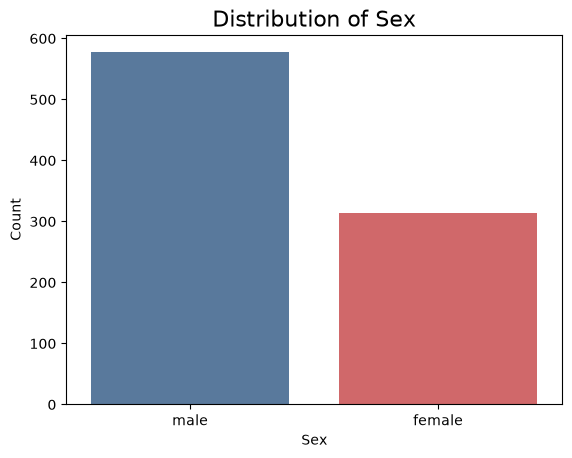

In [46]:
sns.countplot(data=data, x='Sex', palette=["#4E79A7", "#E15759"])
plt.title("Distribution of Sex", fontsize=16)
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

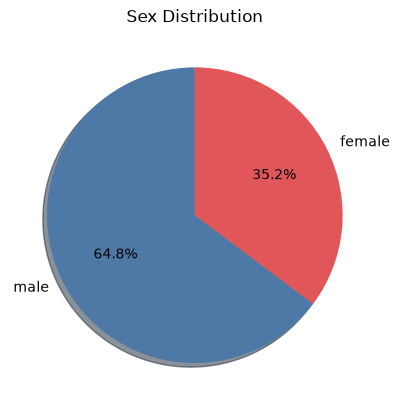

In [47]:
data['Sex'].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90, shadow=True, colors=["#4E79A7", "#E15759"])
plt.ylabel("")
plt.title("Sex Distribution")
plt.show()

In [48]:
counts = data["Sex"].value_counts()

print(f"Total Passengers : {len(data)}")
print(f"Male Passengers  : {counts['male']}")
print(f"Female Passengers: {counts['female']}")

print()

print(f"Male (%)   : {(counts['male']/len(data))*100:.2f}%")
print(f"Female (%) : {(counts['female']/len(data))*100:.2f}%")

Total Passengers : 891
Male Passengers  : 577
Female Passengers: 314

Male (%)   : 64.76%
Female (%) : 35.24%


### Univariate Analysis on `Embarked`

**Conclusions**

- `Embarked` is a **nominal categorical** feature with **2 missing values** (~0.22%).
- The majority of passengers (**72.3%**) embarked from **Southampton (S)**.
- **Cherbourg (C)** accounts for **18.9%**, while **Queenstown (Q)** accounts for **8.6%** of passengers.
- The distribution is **highly imbalanced**, with **Southampton** being the dominant embarkation port.
- Since only **2 values are missing**, they can be safely imputed using the **mode (`S`)**.
- `Embarked` may be an **important feature** for predicting survival and should be analyzed further with the `Survived` column.

In [49]:
data['Embarked'].dtype

<StringDtype(na_value=nan)>

In [52]:
data['Embarked'].isnull().sum()

np.int64(2)

In [51]:
data[data['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [53]:
data['Embarked'].nunique()

3

In [54]:
data['Embarked'].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [57]:
data['Embarked'].value_counts(dropna=False)

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [58]:
(data['Embarked'].value_counts(dropna=False, normalize=True) * 100).round(2)

Embarked
S      72.28
C      18.86
Q       8.64
NaN     0.22
Name: proportion, dtype: float64

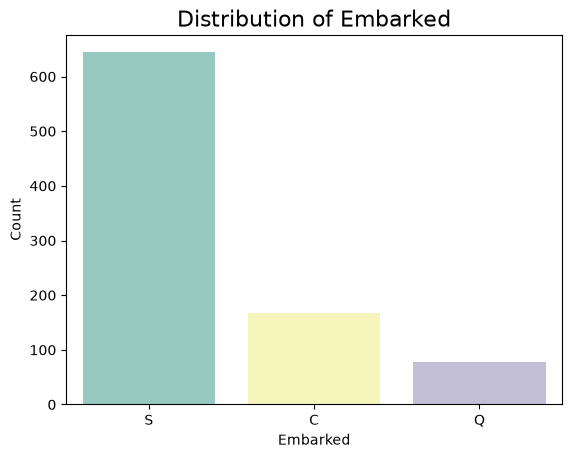

In [60]:
sns.countplot(data=data, x='Embarked', palette="Set3")
plt.title("Distribution of Embarked", fontsize=16)
plt.xlabel("Embarked")
plt.ylabel("Count")
plt.show()

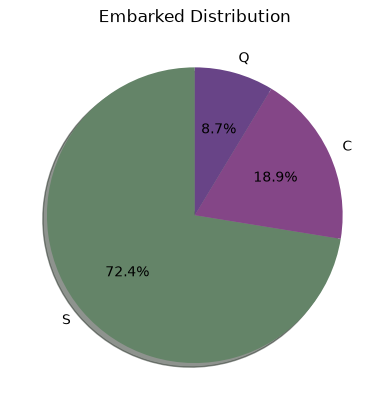

In [62]:
data['Embarked'].value_counts().plot(kind='pie', autopct="%1.1f%%", startangle=90, shadow=True, colors=["#648468","#844687","#684487"])
plt.ylabel("")
plt.title("Embarked Distribution")
plt.show()

In [63]:
counts = data["Embarked"].value_counts()

print(f"Total Passengers : {len(data)}")
print(f"Southampton (S)  : {counts['S']}")
print(f"Cherbourg (C)   : {counts['C']}")
print(f"Queenstown (Q)  : {counts['Q']}")

print()

print(f"Southampton (%) : {(counts['S']/len(data))*100:.2f}%")
print(f"Cherbourg (%)   : {(counts['C']/len(data))*100:.2f}%")
print(f"Queenstown (%)  : {(counts['Q']/len(data))*100:.2f}%")

Total Passengers : 891
Southampton (S)  : 644
Cherbourg (C)   : 168
Queenstown (Q)  : 77

Southampton (%) : 72.28%
Cherbourg (%)   : 18.86%
Queenstown (%)  : 8.64%
